# HealthConnect Clinic Experience Lab
## Week 6: Advanced Analytics & Decision Support

**Track:** Data Analytics  
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

### Week 5 → Week 6 Transition

Week 5 established the analytical foundation for the HealthConnect project through data preparation, KPI calculation, exploratory analysis and dashboard development.

The strongest observed patterns were associated with:
- booking lead time,
- previous no-show history,
- distance to the clinic,
- reminder activity,
- and appointment type.

However, the Week 5 findings were mainly descriptive.

Week 6 therefore focuses on validating the strongest findings, investigating interactions between important variables, integrating findings from the Data Science track, and translating the combined evidence into decision-support recommendations for HealthConnect.

## Week 6 Objectives

The objectives of this analysis are to:

1. Validate the major Week 5 KPIs and findings.
2. Conduct deeper analysis of the strongest no-show patterns.
3. Investigate interactions between important patient and appointment characteristics.
4. Integrate outputs received from the Data Science track.
5. Translate the combined analytical and predictive evidence into practical recommendations.
6. Identify limitations and integration issues.
7. Define analytical testing requirements for Week 7.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    brier_score_loss
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

### Libraries Used

- **Pandas** and **NumPy** for data preparation and analysis.
- **Matplotlib** for visualisation.
- **SciPy** for statistical validation.
- **Scikit-learn metrics** for validating the scoring output received from the Data Science track.

In [3]:
appointments = pd.read_csv(r"C:\Users\BADA\Downloads\Data Analysis\Analyst lab\HealthConnect_Clinic_Experience_Lab\Data\Processed\HealthConnect_Appointment_Data_Cleaned_V2.csv")
coefficients = pd.read_csv(r"C:\Users\BADA\Downloads\Data Analysis\Analyst lab\HealthConnect_Clinic_Experience_Lab\Data\Processed\Integrated Data Files\feature_importances_refined.csv")
scoring = pd.read_csv(r"C:\Users\BADA\Downloads\Data Analysis\Analyst lab\HealthConnect_Clinic_Experience_Lab\Data\Processed\Integrated Data Files\healthconnect_scoring_output.csv")

In [4]:
print("Appointment data:", appointments.shape)
print("Coefficient data:", coefficients.shape)
print("Scoring data:", scoring.shape)

display(appointments.head())
display(coefficients.head())
display(scoring.head())

Appointment data: (5000, 18)
Coefficient data: (34, 2)
Scoring data: (966, 4)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3000,29.0000,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3000,42.0000,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4000,11.0000,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4000,35.0000,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6000,27.0000,No-Show


,Unnamed: 0,0
0,booking_lead_days,0.5957
1,previous_appointments,-0.0601
2,previous_no_shows,0.3066
3,distance_to_clinic_km,0.1672
4,booking_month,-0.0747


,appointment_id,actual_outcome,predicted_no_show_probability,predicted_class
0,0,0,0.4714,0
1,1,0,0.5805,1
2,2,1,0.5127,1
3,3,0,0.4336,0
4,4,1,0.7339,1


## Data Sources

Three datasets are used in the Week 6 analysis:

- The cleaned HealthConnect appointment dataset.
- A Logistic Regression coefficient output received from the Data Science track.
- A model scoring output containing actual outcomes, predicted probabilities and predicted classes.

The original HealthConnect dataset remains the primary source for business analysis. The Data Science outputs are used for cross-track integration and model validation.

In [5]:
appointments["booking_date"] = pd.to_datetime(
    appointments["booking_date"]
)

appointments["appointment_date"] = pd.to_datetime(
    appointments["appointment_date"]
)

attendance_df = appointments[
    appointments["appointment_outcome"].isin(
        ["Attended", "No-Show"]
    )
].copy()

attendance_df["no_show_flag"] = (
    attendance_df["appointment_outcome"] == "No-Show"
).astype(int)

attendance_df.shape

(4737, 19)

In [6]:
attendance_df["appointment_outcome"].value_counts()

appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64

### Eligible Appointment Population

The primary no-show analysis includes only appointments where the patient either attended or failed to attend.

Cancelled appointments are excluded because cancellation is a separate operational outcome and should not be classified as a no-show.

This leaves 4,737 eligible appointment opportunities.

In [7]:
total_appointments = len(appointments)

eligible_appointments = len(attendance_df)

total_no_shows = (
    attendance_df["appointment_outcome"] == "No-Show"
).sum()

total_attended = (
    attendance_df["appointment_outcome"] == "Attended"
).sum()

total_cancelled = (
    appointments["appointment_outcome"] == "Cancelled"
).sum()

no_show_rate = total_no_shows / eligible_appointments

cancellation_rate = total_cancelled / total_appointments

print(f"Total Appointments: {total_appointments:,}")
print(f"Eligible Appointments: {eligible_appointments:,}")
print(f"No-Shows: {total_no_shows:,}")
print(f"Attended: {total_attended:,}")
print(f"Cancelled: {total_cancelled:,}")
print(f"No-Show Rate: {no_show_rate:.2%}")
print(f"Cancellation Rate: {cancellation_rate:.2%}")

Total Appointments: 5,000
Eligible Appointments: 4,737
No-Shows: 2,423
Attended: 2,314
Cancelled: 263
No-Show Rate: 51.15%
Cancellation Rate: 5.26%


### KPI Validation

The Week 5 KPI definitions were revalidated before conducting advanced analysis.

- Total appointments: 5,000
- Eligible appointments: 4,737
- No-shows: 2,423
- Attended: 2,314
- Overall no-show rate: approximately 51.15%
- Cancellation rate: approximately 5.26%

The Week 5 baseline therefore remains valid and is retained for Week 6.

In [8]:
attendance_df["lead_time_band_week6"] = pd.cut(
    attendance_df["booking_lead_days"],
    bins=[-1, 7, 21, 40, 60],
    labels=[
        "0-7 days",
        "8-21 days",
        "22-40 days",
        "41-60 days"
    ],
    include_lowest=True
)

In [9]:
attendance_df["any_prev_no_show"] = np.where(
    attendance_df["previous_no_shows"] > 0,
    "Previous no-show",
    "No previous no-show"
)

attendance_df["high_prev_no_show"] = np.where(
    attendance_df["previous_no_shows"] >= 2,
    "2+ previous no-shows",
    "<2 previous no-shows"
)

In [10]:
attendance_df["distance_band"] = pd.cut(
    attendance_df["distance_to_clinic_km"],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=[
        "<5 km",
        "5-10 km",
        "10-20 km",
        "20+ km"
    ],
    right=False
)

## Week 6 Segment Refinement

Lead-time categories were revised to align the Data Analytics analysis with the segmentation used by the Data Science track.

The Week 6 lead-time bands are:

- 0–7 days
- 8–21 days
- 22–40 days
- 41–60 days

A separate analytical flag was also created for patients with 2 or more previous no-shows.

This definition is used for Data Analytics validation and should not be assumed to be identical to a Data Science engineered feature unless confirmed from its source code.

In [11]:
def no_show_summary(df, group_column):
    summary = (
        df.groupby(group_column, observed=False)["no_show_flag"]
        .agg(
            appointments="size",
            no_shows="sum",
            no_show_rate="mean"
        ).reset_index()
    )

    summary["no_show_rate_pct"] = (summary["no_show_rate"]*100).round(2)
    return summary

In [12]:
lead_time_summary = no_show_summary(
    attendance_df,
    "lead_time_band_week6"
)

lead_time_summary

,lead_time_band_week6,appointments,no_shows,no_show_rate,no_show_rate_pct
0,0-7 days,604,178,0.2947,29.4700
1,8-21 days,1148,448,0.3902,39.0200
2,22-40 days,1484,769,0.5182,51.8200
3,41-60 days,1501,1028,0.6849,68.4900


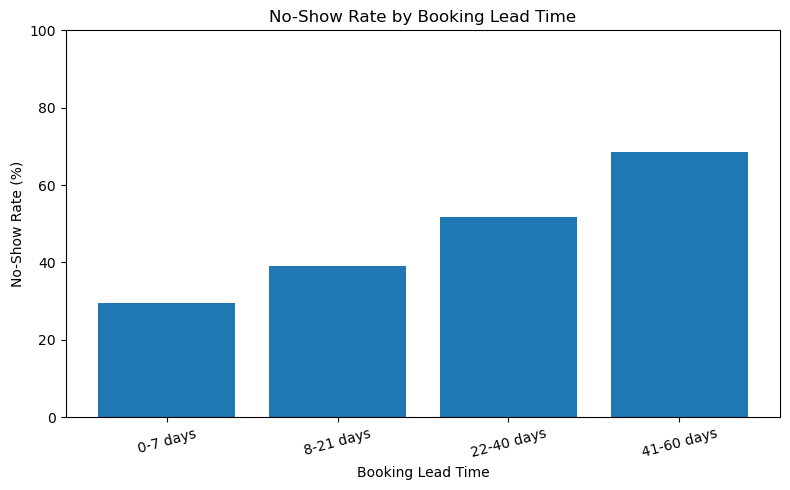

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    lead_time_summary["lead_time_band_week6"].astype(str),
    lead_time_summary["no_show_rate_pct"]
)

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Finding 1: Booking Lead Time Remains the Strongest Pattern

The no-show rate increases steadily as the time between booking and the scheduled appointment becomes longer.

- 0–7 days: approximately 29.5%
- 8–21 days: approximately 39.0%
- 22–40 days: approximately 51.8%
- 41–60 days: approximately 68.5%

This provides stronger evidence than the broader Week 5 grouping and suggests that long-lead appointments should receive greater operational attention.

In [14]:
history_summary = no_show_summary(
    attendance_df,
    "any_prev_no_show"
)

history_summary

,any_prev_no_show,appointments,no_shows,no_show_rate,no_show_rate_pct
0,No previous no-show,2745,1271,0.4630,46.3000
1,Previous no-show,1992,1152,0.5783,57.8300


In [15]:
high_history_summary = no_show_summary(
    attendance_df,
    "high_prev_no_show"
)

high_history_summary

,high_prev_no_show,appointments,no_shows,no_show_rate,no_show_rate_pct
0,2+ previous no-shows,510,324,0.6353,63.5300
1,<2 previous no-shows,4227,2099,0.4966,49.6600


### Finding 2: Previous Attendance Behaviour Remains Important

Patients with at least one previous no-show recorded a no-show rate of approximately 57.8%, compared with approximately 46.3% among those without a previous no-show.

When the segment is restricted to patients with 2 or more previous no-shows, the observed no-show rate increases further.

This supports the use of previous appointment history as a priority variable, although it should be used to support patients rather than automatically restrict access.

In [16]:
def chi_square_test(df, group_column):
    table = pd.crosstab(
        df[group_column],
        df["no_show_flag"]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    rows, cols = table.shape

    denominator = min(rows - 1, cols - 1)

    cramers_v = np.sqrt(
        chi2 / (n * denominator)
    ) if denominator > 0 else np.nan

    return pd.Series({
        "Variable": group_column,
        "Chi-square": chi2,
        "p-value": p_value,
        "Cramers V": cramers_v
    })

**Testing the main variables**

In [17]:
validation_results = pd.DataFrame([
    chi_square_test(
        attendance_df,
        "lead_time_band_week6"
    ),

    chi_square_test(
        attendance_df,
        "any_prev_no_show"
    ),

    chi_square_test(
        attendance_df,
        "high_prev_no_show"
    ),

    chi_square_test(
        attendance_df.dropna(
            subset=["distance_band"]
        ),
        "distance_band"
    ),

    chi_square_test(
        attendance_df,
        "reminder_sent"
    ),

    chi_square_test(
        attendance_df,
        "appointment_type"
    ),

    chi_square_test(
        attendance_df,
        "appointment_time"
    ),

    chi_square_test(
        attendance_df,
        "appointment_day"
    ),

    chi_square_test(
        attendance_df,
        "age_group"
    )
])

validation_results.sort_values(
    "Cramers V",
    ascending=False
)

,Variable,Chi-square,p-value,Cramers V
0,lead_time_band_week6,362.0066,0.0000,0.2764
1,any_prev_no_show,60.9437,0.0000,0.1134
2,high_prev_no_show,34.4976,0.0000,0.0853
3,distance_band,17.9616,0.0004,0.0621
5,appointment_type,8.4221,0.0380,0.0422
4,reminder_sent,8.3556,0.0038,0.0420
8,age_group,6.8010,0.2359,0.0379
7,appointment_day,6.3771,0.3823,0.0367
6,appointment_time,0.7796,0.6772,0.0128


## Statistical Validation of Week 5 Findings

Chi-square tests were used to assess whether selected categorical variables were associated with appointment outcome.

Cramer's V was also calculated to measure the relative strength of each association.

The purpose is not to prove causation, but to determine which Week 5 patterns deserve greater analytical and operational attention.

## Chi-Square Test & Cramér's V Feature Analysis

### 📊 Summary Table

| Rank | Variable | Chi-square | p-value | Cramér's V | Significance ($p \le 0.05$) | Association Strength |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | `lead_time_band_week6` | 362.0066 | 0.0000 | 0.2764 | **Significant** | Moderate / Strong |
| **2** | `any_prev_no_show` | 60.9437 | 0.0000 | 0.1134 | **Significant** | Weak / Moderate |
| **3** | `high_prev_no_show` | 34.4976 | 0.0000 | 0.0853 | **Significant** | Weak |
| **4** | `distance_band` | 17.9616 | 0.0004 | 0.0621 | **Significant** | Weak |
| **5** | `reminder_sent` | 8.3556 | 0.0038 | 0.0420 | **Significant** | Very Weak |
| **6** | `appointment_type` | 8.4221 | 0.0380 | 0.0422 | **Significant** | Very Weak |
| **7** | `age_group` | 6.8010 | 0.2359 | 0.0379 | *Not Significant* | None |
| **8** | `appointment_day` | 6.3771 | 0.3823 | 0.0367 | *Not Significant* | None |
| **9** | `appointment_time` | 0.7796 | 0.6772 | 0.0128 | *Not Significant* | None |

---

### 💡 Key Insights & Next Steps

1. **Top Drivers of No-Shows:**
   * **Booking Lead Time (`lead_time_band_week6`):** Standard-bearer metric for predicting non-attendance ($\text{Cramér's V} = 0.2764$).
   * **Past Behavior (`any_prev_no_show`, `high_prev_no_show`):** Patient history matters significantly; prior no-shows are reliable predictors of future no-shows.

2. **Features to Keep for Modeling:**
   * `lead_time_band_week6`
   * `any_prev_no_show`
   * `high_prev_no_show`
   * `distance_band`
   * `reminder_sent`
   * `appointment_type`

3. **Features to Consider Dropping:**
   * `age_group`, `appointment_day`, and `appointment_time` failed to achieve statistical significance ($p > 0.05$) and carry negligible effect sizes ($\text{Cramér's V} < 0.04$).

- Booking lead time produced the strongest association with no-show outcome.
- Previous no-show history also showed a meaningful relationship.
- Distance, reminders, and appointment type showed smaller associations, while age group, appointment day, and appointment time were comparatively weak.

This evidence was used to prioritise the remaining Week 6 analysis.

In [18]:
lead_history = (
    attendance_df.groupby(
        [
            "lead_time_band_week6",
            "high_prev_no_show"
        ],
        observed=False
    )["no_show_flag"]
    .agg(
        appointments="size",
        no_shows="sum",
        no_show_rate="mean"
    )
    .reset_index()
)

lead_history["no_show_rate_pct"] = (
    lead_history["no_show_rate"]*100
)

lead_history

,lead_time_band_week6,high_prev_no_show,appointments,no_shows,no_show_rate,no_show_rate_pct
0,0-7 days,2+ previous no-shows,72,34,0.4722,47.2222
1,0-7 days,<2 previous no-shows,532,144,0.2707,27.0677
2,8-21 days,2+ previous no-shows,138,74,0.5362,53.6232
3,8-21 days,<2 previous no-shows,1010,374,0.3703,37.0297
4,22-40 days,2+ previous no-shows,144,86,0.5972,59.7222
5,22-40 days,<2 previous no-shows,1340,683,0.5097,50.9701
6,41-60 days,2+ previous no-shows,156,130,0.8333,83.3333
7,41-60 days,<2 previous no-shows,1345,898,0.6677,66.7658


In [19]:
lead_history_matrix = lead_history.pivot(
    index="high_prev_no_show",
    columns="lead_time_band_week6",
    values="no_show_rate_pct"
)

lead_history_matrix

lead_time_band_week6,0-7 days,8-21 days,22-40 days,41-60 days
high_prev_no_show,,,,
2+ previous no-shows,47.2222,53.6232,59.7222,83.3333
<2 previous no-shows,27.0677,37.0297,50.9701,66.7658


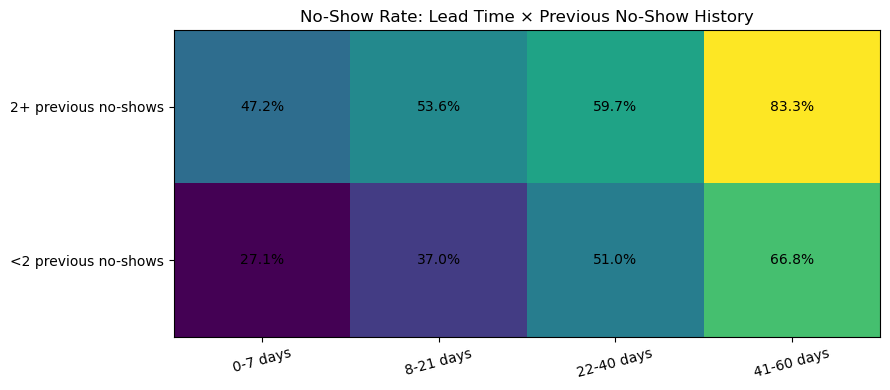

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

image = ax.imshow(
    lead_history_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(lead_history_matrix.columns))
)

ax.set_xticklabels(
    lead_history_matrix.columns.astype(str),
    rotation=15
)

ax.set_yticks(
    range(len(lead_history_matrix.index))
)

ax.set_yticklabels(
    lead_history_matrix.index
)

for row in range(
    lead_history_matrix.shape[0]
):
    for col in range(
        lead_history_matrix.shape[1]
    ):
        value = lead_history_matrix.iloc[row, col]

        ax.text(
            col,
            row,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.title(
    "No-Show Rate: Lead Time × Previous No-Show History"
)

plt.tight_layout()
plt.show()

### Finding 3: Risk Increases When Long Lead Time and Repeated No-Show History Occur Together

The highest observed no-show rate occurred among appointments booked 41–60 days in advance for patients with 2 or more previous no-shows.

This segment recorded an observed no-show rate of approximately 83.3%, representing 130 no-shows from 156 eligible appointments.

This is substantially higher than the overall no-show rate of 51.15% and supports further testing of lead-time and history interactions by the Data Science track.

In [21]:
lead_reminder = (
    attendance_df
    .groupby(
        [
            "lead_time_band_week6",
            "reminder_sent"
        ],
        observed=False
    )["no_show_flag"]
    .agg(
        appointments="size",
        no_shows="sum",
        no_show_rate="mean"
    )
    .reset_index()
)

lead_reminder["no_show_rate_pct"] = (
    lead_reminder["no_show_rate"] * 100
)

lead_reminder

,lead_time_band_week6,reminder_sent,appointments,no_shows,no_show_rate,no_show_rate_pct
0,0-7 days,No,160,50,0.3125,31.2500
1,0-7 days,Yes,444,128,0.2883,28.8288
2,8-21 days,No,312,136,0.4359,43.5897
3,8-21 days,Yes,836,312,0.3732,37.3206
4,22-40 days,No,420,227,0.5405,54.0476
5,22-40 days,Yes,1064,542,0.5094,50.9398
6,41-60 days,No,393,289,0.7354,73.5369
7,41-60 days,Yes,1108,739,0.6670,66.6968


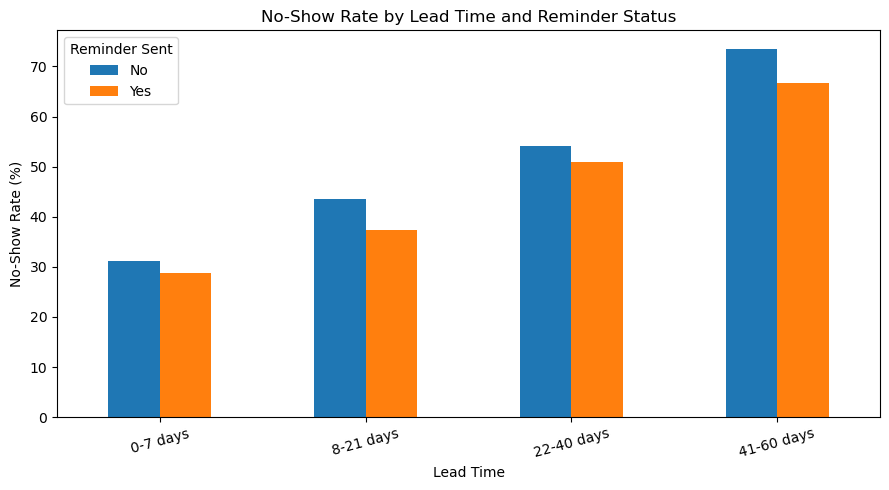

In [22]:
pivot_reminder = lead_reminder.pivot(
    index="lead_time_band_week6",
    columns="reminder_sent",
    values="no_show_rate_pct"
)

pivot_reminder.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "No-Show Rate by Lead Time and Reminder Status"
)
plt.xlabel("Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=15)
plt.legend(title="Reminder Sent")

plt.tight_layout()
plt.show()

### Finding 4: Reminder-Associated Appointments Show Lower Rates Within Each Lead-Time Band

Appointments with reminders recorded lower observed no-show rates within every lead-time category.

However, this analysis is observational. Reminder assignment may not be random, so the results should be treated as evidence for a future intervention test rather than proof that reminders cause improved attendance.

In [23]:
lead_distance = (
    attendance_df
    .dropna(
        subset=["distance_band"]
    )
    .groupby(
        [
            "lead_time_band_week6",
            "distance_band"
        ],
        observed=False
    )["no_show_flag"]
    .agg(
        appointments="size",
        no_shows="sum",
        no_show_rate="mean"
    )
    .reset_index()
)

lead_distance["no_show_rate_pct"] = (
    lead_distance["no_show_rate"] * 100
)

lead_distance

,lead_time_band_week6,distance_band,appointments,no_shows,no_show_rate,no_show_rate_pct
0,0-7 days,<5 km,140,34,0.2429,24.2857
1,0-7 days,5-10 km,197,50,0.2538,25.3807
2,0-7 days,10-20 km,197,66,0.3350,33.5025
3,0-7 days,20+ km,57,23,0.4035,40.3509
4,8-21 days,<5 km,249,77,0.3092,30.9237
5,8-21 days,5-10 km,395,155,0.3924,39.2405
6,8-21 days,10-20 km,406,168,0.4138,41.3793
7,8-21 days,20+ km,79,40,0.5063,50.6329
8,22-40 days,<5 km,332,173,0.5211,52.1084
9,22-40 days,5-10 km,504,245,0.4861,48.6111


### Finding 5: Distance Appears to Compound Long Lead-Time Risk

Patients travelling 20 km or more recorded higher observed no-show rates than shorter-distance groups.

Among appointments booked 41–60 days in advance, the 20+ km group recorded an observed no-show rate of approximately 72.9%.

This suggests that scheduling delay and travel burden may represent a useful combined operational segment.

In [24]:
type_history = (
    attendance_df
    .groupby(
        [
            "appointment_type",
            "high_prev_no_show"
        ],
        observed=False
    )["no_show_flag"]
    .agg(
        appointments="size",
        no_shows="sum",
        no_show_rate="mean"
    )
    .reset_index()
)

type_history["no_show_rate_pct"] = (
    type_history["no_show_rate"] * 100
)

type_history

,appointment_type,high_prev_no_show,appointments,no_shows,no_show_rate,no_show_rate_pct
0,Diagnostic Test,2+ previous no-shows,70,44,0.6286,62.8571
1,Diagnostic Test,<2 previous no-shows,497,251,0.5050,50.5030
2,Follow-up,2+ previous no-shows,149,102,0.6846,68.4564
3,Follow-up,<2 previous no-shows,1195,626,0.5238,52.3849
4,General Consultation,2+ previous no-shows,203,121,0.5961,59.6059
5,General Consultation,<2 previous no-shows,1777,852,0.4795,47.9460
6,Specialist Consultation,2+ previous no-shows,88,57,0.6477,64.7727
7,Specialist Consultation,<2 previous no-shows,758,370,0.4881,48.8127


### Finding 6: Follow-Up Appointments Become More Important When Combined with Previous History

Follow-up appointments alone showed only a moderate elevation in no-show rate.

However, among patients with 2 or more previous no-shows, follow-up appointments recorded a substantially higher rate.

This suggests that appointment type may be more useful as an interaction variable than as a standalone predictor.

## Cross-Track Integration with Data Science

Week 6 required a meaningful cross-track integration activity.

The Data Analytics track collaborated with the Data Science track in two directions:

**Analytics → Data Science**

Validated findings were shared relating to:
- booking lead time,
- previous no-show history,
- distance,
- reminders,
- appointment type,
- and high-risk interactions.

These findings were intended to support feature refinement and model error analysis.

**Data Science → Analytics**

The Data Science track provided:
- model feature information,
- Logistic Regression coefficients,
- predicted probabilities,
- predicted classes,
- and threshold-related information.

These outputs were incorporated into the Week 6 analysis to assess whether the predictive results aligned with the descriptive business patterns.

In [25]:
coefficients.columns = [
    "feature",
    "coefficient"
]
coefficients.head()

,feature,coefficient
0,booking_lead_days,0.5957
1,previous_appointments,-0.0601
2,previous_no_shows,0.3066
3,distance_to_clinic_km,0.1672
4,booking_month,-0.0747


In [27]:
coefficients["abs_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients["direction"] = np.where(
    coefficients["coefficient"] > 0,
    "Higher predicted no-show probability",
    "Lower predicted no-show probability"
)

coefficients_sorted = (
    coefficients.sort_values(
        "abs_coefficient",
        ascending=False
    )
)
coefficients_sorted.head(15)

,feature,coefficient,abs_coefficient,direction
0,booking_lead_days,0.5957,0.5957,Higher predicted no-show probability
2,previous_no_shows,0.3066,0.3066,Higher predicted no-show probability
26,appointment_day_Wednesday,0.2589,0.2589,Higher predicted no-show probability
30,reminder_channel_No Reminder,0.2324,0.2324,Higher predicted no-show probability
24,appointment_day_Thursday,0.2214,0.2214,Higher predicted no-show probability
9,appointment_day_of_year,0.2130,0.2130,Higher predicted no-show probability
12,gender_Prefer not to say,-0.2048,0.2048,Lower predicted no-show probability
8,appointment_month,-0.1940,0.1940,Lower predicted no-show probability
19,appointment_type_General Consultation,-0.1770,0.1770,Lower predicted no-show probability
3,distance_to_clinic_km,0.1672,0.1672,Higher predicted no-show probability


<function matplotlib.pyplot.show(close=None, block=None)>

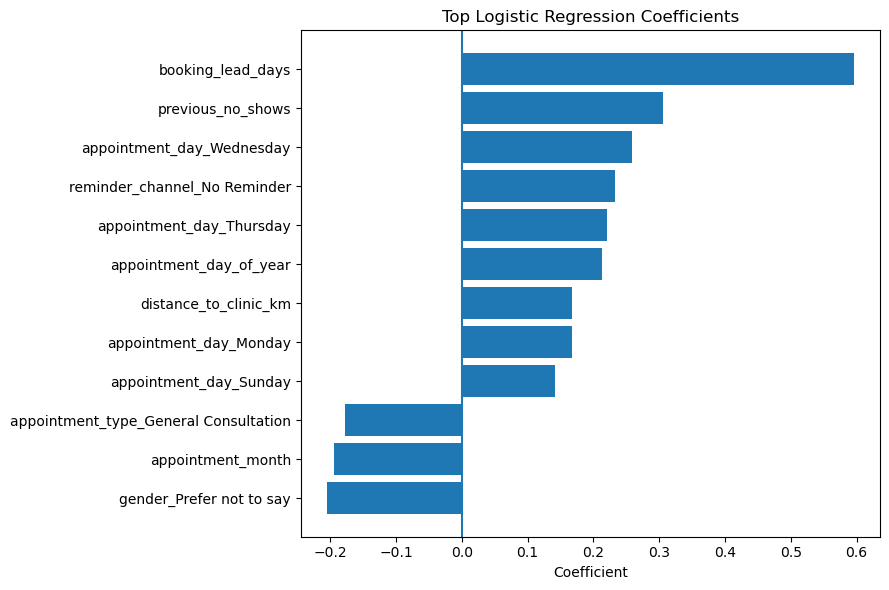

In [29]:
top_coefficients = (
    coefficients_sorted
    .head(12)
    .sort_values("coefficient")
)

plt.figure(figsize=(9,6))

plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"]
)

plt.axvline(0)

plt.title(
    "Top Logistic Regression Coefficients"
)
plt.xlabel(
    "Coefficient"
)
plt.tight_layout()
plt.show

## Logistic Regression Feature Importance Analysis

This plot displays the **log-odds coefficients** from the Logistic Regression model, highlighting the relative influence and direction of each feature on predicting appointment **no-shows**.

---

### 📊 Model Coefficient Summary

| Feature | Coefficient | Influence Type | Interpretation |
| :--- | :--- | :--- | :--- |
| **`booking_lead_days`** | $\approx +0.60$ | **Strong Risk Factor** | Longer booking gaps heavily increase no-show probability. |
| **`previous_no_shows`** | $\approx +0.31$ | **Moderate Risk Factor** | History of past no-shows strongly predicts future no-shows. |
| **`appointment_day_Wednesday`** | $\approx +0.26$ | **Risk Factor** | Wednesday bookings experience higher non-attendance. |
| **`reminder_channel_No Reminder`** | $\approx +0.23$ | **Risk Factor** | Omitting reminders increases likelihood of missed visits. |
| **`appointment_day_Thursday`** | $\approx +0.22$ | **Risk Factor** | Thursday bookings show elevated no-show risk. |
| **`appointment_day_of_year`** | $\approx +0.21$ | **Risk Factor** | General seasonal creep upward in non-attendance over time. |
| **`distance_to_clinic_km`** | $\approx +0.17$ | **Risk Factor** | Living farther from the clinic increases no-show likelihood. |
| **`appointment_day_Monday`** | $\approx +0.17$ | **Risk Factor** | Monday appointments have increased no-show risk. |
| **`appointment_day_Sunday`** | $\approx +0.14$ | **Risk Factor** | Sunday appointments carry a slight risk increase. |
| **`appointment_type_General Consultation`** | $\approx -0.18$ | **Protective Factor** | General consultations show lower non-attendance rates. |
| **`appointment_month`** | $\approx -0.19$ | **Protective Factor** | Certain months demonstrate lower baseline no-show rates. |
| **`gender_Prefer not to say`** | $\approx -0.20$ | **Protective Factor** | Associated with lower probability of missing appointments. |

---

### 💡 Core Takeaways

* **Lead Time and Past History are Paramount:** The two single largest drivers of no-shows are how far out the appointment is scheduled (`booking_lead_days`) and prior patient non-attendance (`previous_no_shows`).
* **Actionable Interventions:** 
  1. Mandate automated reminders (`reminder_channel_No Reminder` carries a positive coefficient).
  2. Implement double-confirmations or shorter scheduling windows for appointments booked far in advance.

### Checking and Validating the Scoring File

In [30]:
scoring.head()
scoring.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   appointment_id                 966 non-null    int64  
 1   actual_outcome                 966 non-null    int64  
 2   predicted_no_show_probability  966 non-null    float64
 3   predicted_class                966 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 30.3 KB


In [31]:
appointments["appointment_id"].head()

0    HC-00001
1    HC-00002
2    HC-00003
3    HC-00004
4    HC-00005
Name: appointment_id, dtype: object

In [32]:
scoring["appointment_id"].head()

0    0
1    1
2    2
3    3
4    4
Name: appointment_id, dtype: int64

### Integration Issue: Scoring File Identifier

The scoring file does not retain the original HealthConnect appointment identifier.

The raw dataset uses identifiers such as `HC-00001`, while the scoring file contains integer test-row identifiers.

Therefore, the scoring file cannot be safely joined to the original appointment dataset at appointment level.

The scoring output is used only for aggregate model validation during Week 6.

A corrected scoring export containing the original `appointment_id` and preferably `patient_id` will be required for Week 7 error analysis.

In [33]:
y_true = scoring["actual_outcome"]

y_prob = scoring[
    "predicted_no_show_probability"
]

y_pred = scoring[
    "predicted_class"
]

In [34]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

auc = roc_auc_score(
    y_true,
    y_prob
)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")
print(f"ROC-AUC: {auc:.3f}")

Accuracy: 63.56%
Precision: 62.97%
Recall: 65.84%
F1 Score: 64.37%
ROC-AUC: 0.689


In [35]:
cm = confusion_matrix(
    y_true,
    y_pred
)

cm

array([[296, 187],
       [165, 318]])

In [36]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 296
False Positives: 187
False Negatives: 165
True Positives: 318


### Model Performance Interpretation

The Logistic Regression scoring output demonstrates moderate predictive performance.

The ROC-AUC of approximately 0.689 indicates that the model has useful but limited ability to distinguish between attended and no-show appointments.

The model should therefore be treated as a decision-support tool rather than an automated decision-making system at this stage.

## Confusion Matrix Breakdown

The Confusion Matrix provides an exact count of correct predictions versus prediction errors for the `no_show_flag` classification model.


### Matrix Components Summary

| Metric | Code Variable | Real Outcome | Model Prediction | Operational Impact |
| :--- | :--- | :--- | :--- | :--- |
| **True Negative (TN)** | `tn` | Attended ($0$) | Attended ($0$) | **Correct:** Standard appointment workflow. |
| **False Positive (FP)** | `fp` | Attended ($0$) | No-Show ($1$) | **False Alarm:** Wasted staff effort contacting patients who planned to attend anyway. |
| **False Negative (FN)** | `fn` | No-Show ($1$) | Attended ($0$) | **Missed Risk:** Clinic suffers lost revenue and unmitigated empty appointment slots. |
| **True Positive (TP)** | `tp` | No-Show ($1$) | No-Show ($1$) | **Correct Catch:** Successfully identified high-risk appointment for intervention. |

* **Business Priority:** Analyzing `fp` vs. `fn` could help the clinic decide whether the cost of **wasting staff time (False Positives)** is higher or lower than the cost of **empty calendar slots (False Negatives)**.

```

In [38]:
scoring["probability_decile"] = pd.qcut(
    scoring[
        "predicted_no_show_probability"
    ],
    q=10,
    duplicates="drop"
)

In [39]:
score_validation = (
    scoring
    .groupby(
        "probability_decile",
        observed=True
    )
    .agg(
        appointments=(
            "actual_outcome",
            "size"
        ),

        avg_predicted_probability=(
            "predicted_no_show_probability",
            "mean"
        ),

        actual_no_show_rate=(
            "actual_outcome",
            "mean"
        )
    )
    .reset_index()
)

score_validation

,probability_decile,appointments,avg_predicted_probability,actual_no_show_rate
0,"(0.161, 0.29]",97,0.2456,0.1649
1,"(0.29, 0.353]",97,0.3223,0.3918
2,"(0.353, 0.403]",96,0.3800,0.3438
3,"(0.403, 0.458]",97,0.4284,0.4742
4,"(0.458, 0.513]",96,0.4867,0.4792
5,"(0.513, 0.57]",97,0.5439,0.5052
6,"(0.57, 0.617]",96,0.5954,0.5625
7,"(0.617, 0.664]",97,0.6403,0.5876
8,"(0.664, 0.726]",96,0.6921,0.7188
9,"(0.726, 0.879]",97,0.7807,0.7732


In [40]:
score_validation[
    "avg_predicted_probability_pct"
] = (
    score_validation[
        "avg_predicted_probability"
    ] * 100
)

score_validation[
    "actual_no_show_rate_pct"
] = (
    score_validation[
        "actual_no_show_rate"
    ] * 100
)
score_validation

,probability_decile,appointments,avg_predicted_probability,actual_no_show_rate,avg_predicted_probability_pct,actual_no_show_rate_pct
0,"(0.161, 0.29]",97,0.2456,0.1649,24.5645,16.4948
1,"(0.29, 0.353]",97,0.3223,0.3918,32.2288,39.1753
2,"(0.353, 0.403]",96,0.3800,0.3438,38.0013,34.3750
3,"(0.403, 0.458]",97,0.4284,0.4742,42.8396,47.4227
4,"(0.458, 0.513]",96,0.4867,0.4792,48.6748,47.9167
5,"(0.513, 0.57]",97,0.5439,0.5052,54.3872,50.5155
6,"(0.57, 0.617]",96,0.5954,0.5625,59.5418,56.2500
7,"(0.617, 0.664]",97,0.6403,0.5876,64.0259,58.7629
8,"(0.664, 0.726]",96,0.6921,0.7188,69.2103,71.8750
9,"(0.726, 0.879]",97,0.7807,0.7732,78.0713,77.3196


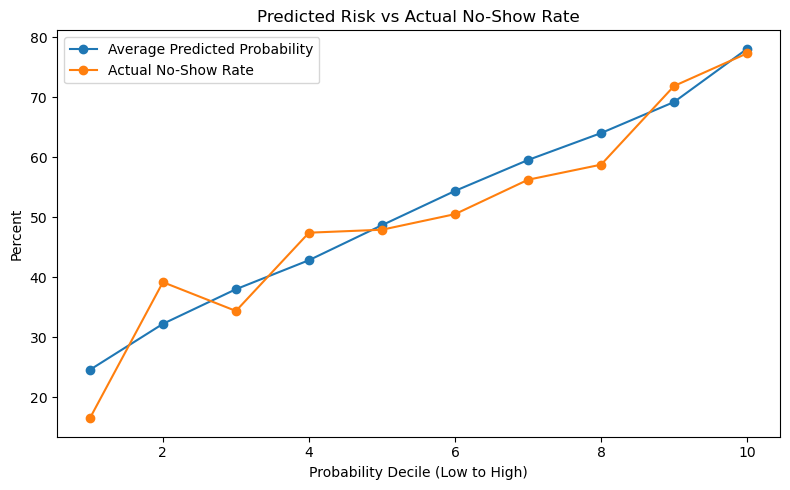

In [41]:
x = np.arange(
    1,
    len(score_validation) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    score_validation[
        "avg_predicted_probability_pct"
    ],
    marker="o",
    label="Average Predicted Probability"
)

plt.plot(
    x,
    score_validation[
        "actual_no_show_rate_pct"
    ],
    marker="o",
    label="Actual No-Show Rate"
)

plt.title(
    "Predicted Risk vs Actual No-Show Rate"
)

plt.xlabel(
    "Probability Decile (Low to High)"
)

plt.ylabel(
    "Percent"
)

plt.legend()

plt.tight_layout()
plt.show()

### Probability Score Validation

The scoring output shows meaningful risk ranking.

Appointments in the lowest predicted-probability decile recorded an actual no-show rate of approximately 16.5%, while the highest predicted-probability decile recorded approximately 77.3%.

This suggests that the probability score contains useful ranking information.

However, these deciles are used for model validation only and should not yet be interpreted as official Low, Medium and High operational risk tiers.

In [43]:
threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.05
):
    predictions = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    threshold_results.append({
        "threshold": round(
            threshold,
            2
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "flag_rate": predictions.mean(),

        "false_positives": fp,

        "false_negatives": fn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1,flag_rate,false_positives,false_negatives
0,0.3000,0.5378,0.9565,0.6885,0.8892,397,21
1,0.3500,0.5561,0.8923,0.6852,0.8023,344,52
2,0.4000,0.5859,0.8261,0.6856,0.7050,282,84
3,0.4500,0.6024,0.7371,0.6629,0.6118,235,127
4,0.5000,0.6297,0.6584,0.6437,0.5228,187,165
5,0.5500,0.6464,0.5714,0.6066,0.4420,151,207
6,0.6000,0.6890,0.4679,0.5573,0.3395,102,257
7,0.6500,0.7339,0.3313,0.4565,0.2257,58,323
8,0.7000,0.7923,0.2133,0.3361,0.1346,27,380


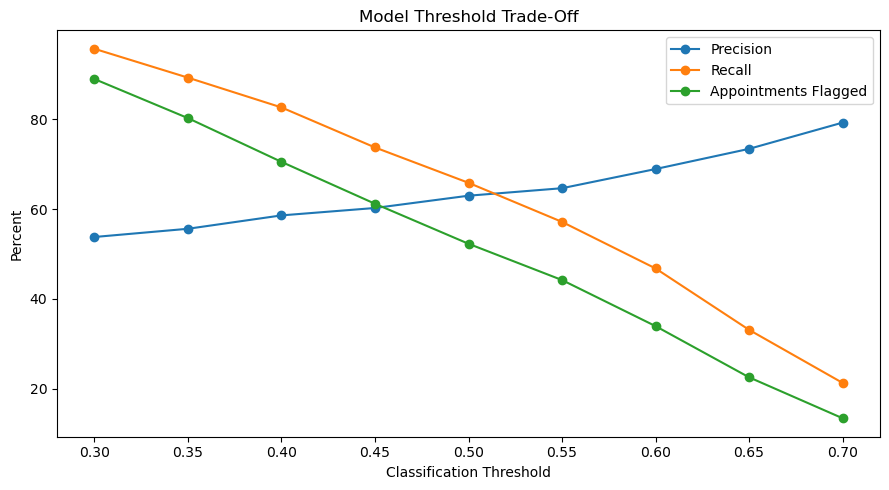

In [44]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"] * 100,
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"] * 100,
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["flag_rate"] * 100,
    marker="o",
    label="Appointments Flagged"
)

plt.title(
    "Model Threshold Trade-Off"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Percent"
)

plt.legend()

plt.tight_layout()
plt.show()

### Threshold Decision Support

Lower classification thresholds identify a larger share of potential no-shows but also increase the number of appointments requiring intervention.

Higher thresholds create more targeted outreach but miss a larger proportion of actual no-shows.

A final threshold cannot be recommended from model performance alone.

HealthConnect would first need to define:
- the cost of a missed no-show,
- the cost of unnecessary outreach,
- and the number of patients staff can realistically contact.

Threshold selection is therefore recommended as a Week 7 decision-support activity.

## 6. Integrated Analytics and Data Science Findings

| Analytics Evidence | Data Science Evidence | Integrated Interpretation |
|---|---|---|
| No-show rate rises strongly with lead time | Lead-time variables are major model drivers | Lead time is the strongest shared risk indicator |
| Previous no-shows have higher observed rates | Previous no-show variables contribute positively to prediction | Patient history is useful for supportive prioritisation |
| 20+ km patients show higher no-show rates | Distance contributes to prediction | Travel/access burden deserves further attention |
| No-reminder appointments show higher observed rates | Reminder-related variables contribute to the model | Reminder strategy should be tested prospectively |
| Follow-up appointments have moderately higher rates | Follow-up contributes modestly to prediction | Appointment type is useful as a secondary/interacting variable |

The cross-track evidence does not prove that these variables cause no-shows.

Rather, the consistency between descriptive Analytics findings and predictive Data Science outputs strengthens the case for prioritising lead time, previous no-show history, distance and reminder-related factors in future testing.

## Business Recommendations

### 1. Prioritise long-lead appointments for reconfirmation

Appointments booked 41–60 days ahead recorded a 68.5% no-show rate.

HealthConnect should consider additional confirmation or reconfirmation closer to the appointment date.

### 2. Test a combined intervention for long lead time and repeated previous no-shows

The 41–60 day + 2+ previous no-show segment recorded an 83.3% observed no-show rate.

This represents the strongest priority segment identified during Week 6.

### 3. Use previous history to support patients rather than restrict access

Previous no-show history is a useful risk signal, but it should be used to identify patients who may benefit from additional support.

### 4. Test reminder timing and channel

Reminder-associated appointments showed lower observed no-show rates, including within each lead-time group.

A controlled pilot should be used before claiming that reminders cause improved attendance.

### 5. Consider travel burden

Patients located 20 km or more from the clinic showed elevated no-show rates, especially for long-lead appointments.

Additional confirmation or scheduling flexibility may be worth testing for this group.

### 6. Do not prioritise age, day or appointment time as primary intervention criteria

These variables showed relatively weak associations compared with lead time and previous no-show history.

## Limitations, Risks and Dependencies

The Week 6 analysis has several important limitations:

- Observational relationships do not establish causality.
- Reminder assignment may not be random.
- Some distance values are missing.
- Some engineered Data Science feature definitions were described as likely definitions rather than confirmed directly from source code.
- The current scoring file does not contain the original HealthConnect appointment ID.
- Model outputs received from different Data Science collaborators may use different preprocessing or train/test configurations.
- Final operational Low/Medium/High risk thresholds have not yet been defined.

## Cross-Track Integration Evidence

**Track collaborated with:** Data Science

**Information received:**
- model feature information,
- Random Forest feature importance,
- Logistic Regression coefficients,
- scoring probabilities and predicted classes,
- threshold and error-analysis information.

**Information provided:**
- validated Analytics findings on lead time,
- previous no-show history,
- reminder patterns,
- distance,
- appointment type,
- and important interaction segments.

**Integration activity completed:**
Data Science outputs were used to prioritise advanced Analytics investigations, while Analytics findings were provided to support feature refinement and error analysis.

**What changed as a result:**
The Week 6 work moved from independent descriptive EDA to model-informed decision support.

The collaboration also identified an important integration problem: the scoring export does not retain the original appointment identifier, preventing reliable row-level model error analysis.

**Evidence:**
- advanced interaction tables,
- validated KPI results,
- statistical testing,
- model score validation,
- updated dashboard,
- cross-track documentation.

## Week 7 Analytical Testing Requirements

The following activities are recommended for Week 7:

1. Obtain a corrected scoring export containing the original `appointment_id` and `patient_id`.
2. Confirm exact engineered-feature definitions from the Data Science source code.
3. Analyse false positives and false negatives by lead time, previous history, reminder status, distance and appointment type.
4. Define the operational cost of false positives and false negatives.
5. Test alternative classification thresholds based on clinic outreach capacity.
6. Validate dashboard KPI calculations against the notebook.
7. Test whether the long-lead + repeated-history segment remains stable under alternative definitions.
8. Compare predicted probability and actual no-show behaviour using a consistent test population.

## Conclusion

Week 6 advanced the HealthConnect Data Analytics work from descriptive reporting to integrated decision support.

Booking lead time remained the strongest observed no-show indicator, while previous no-show history provided an important behavioural signal.

The strongest combined segment consisted of appointments booked 41–60 days in advance for patients with 2 or more previous no-shows, where the observed no-show rate reached approximately 83.3%.

Cross-track integration with Data Science showed broad agreement between the strongest descriptive patterns and the variables contributing to predictive risk.

The model probability scores also demonstrated useful risk ranking, although operational thresholds and row-level error analysis require further work in Week 7.

Overall, the Week 6 findings support a move toward targeted reconfirmation, supportive outreach and evidence-based testing rather than uniform intervention across all appointments.